| Technological Institute of the Philippines | Quezon City - Computer Engineering |
|-------------------------------------------|------------------------------------|
| **Course Code:** | CPE 027 |
| **Code Title:** | Digital Signal Processing and Applications |
| **1st Semester** | AY 2026-2027 |
| **ACTIVITY NO. 11** | **Simple Equalizer** |
| **Name:** | Pascual, Ken Leonard <br> Lim, Justian Adrian <br> Bueno, Joshua <br> Deniega, Alexis <br> Carag, Carl Jervie <br> Jimenez, Christian Joros R.|
| **Section:** | CPE41S2 |
| **Date Performed:** | 2 October 2026 |
| **Date Submitted:** | 2 October 2026 |
| **Instructor:** | Engr. Jimlord M. Quejado |

## 1. Objectives

This activity aims to create a simple equalizer that will use various digital filters.

## 2. Intended Learning Outcomes (ILOs)
After completion of this activity, the students should be able to:

1. Implement the various filter configuration in a signal processing application.

## 3. Discussion


There are several ways to calculate the Discrete Fourier Transform (DFT), such as solving simultaneous Digital filters are used for two general purposes: (1) separation of signals that have been combined, and (2) restoration of signals that have been distorted in some way. Analog (electronic) filters can be used for these same tasks; however, digital filters can achieve far superior results. The most popular digital filters are described and compared in the next seven chapters. This introductory chapter describes the parameters you want to look for when learning about each of these filters. 

Digital filters are a very important part of DSP. In fact, their extraordinary performance is one of the key reasons that DSP has become so popular. As mentioned in the introduction, filters have two uses: signal separation and signal restoration. Signal separation is needed when a signal has been contaminated with interference, noise, or other signals. For example, imagine a device for measuring the electrical activity of a baby's heart (ECG) while still in the womb. The raw signal will likely be corrupted by the breathing and heartbeat of the mother. A filter might be used to separate these signals so that they can be individually analyzed. 

## 4. Resources
The activity will require the following software, tools and equipment:
* IDE or any online code editor

## 5. Directions:

### Song 1: Perfume - Polyrhythm

#### 1. Download your favorite song and plot the first 20 seconds of it.

##### Import the audio file

In [11]:
import os
import shutil
import subprocess
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# --- File locations -------------------------------------------------
# The notebook lives in HOA11/, so look for HOA11/audio relative to the
# current working directory (also works when launched from the repo root).
BASE_DIR = Path.cwd()
if not (BASE_DIR / "audio" / "raw").is_dir() and (BASE_DIR / "HOA11" / "audio" / "raw").is_dir():
    BASE_DIR = BASE_DIR / "HOA11"

RAW_DIR     = BASE_DIR / "audio" / "raw"      # source songs (.flac)
TRIMMED_DIR = BASE_DIR / "audio" / "trimmed"  # trimmed clips (.wav)
VIS_DIR     = BASE_DIR / "visualizations"        # plots (.png)
VIS_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR     = BASE_DIR / "audio" / "outputs"       # audio of each stage (.wav)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Song 1: Perfume - Polyrhythm
AUDIO_FILE = RAW_DIR / "Perfurme-Polyrhythm.flac"

# --- Saving every plot ------------------------------------------------
# Every plotting cell calls save_fig("<name>.png", fig) right before
# plt.show(), so all figures land in HOA11/visualizations.
def save_fig(name, fig=None, dpi=150):
    """Save a figure to HOA11/visualizations and echo the file path."""
    if fig is None:
        fig = plt.gcf()
    path = VIS_DIR / name
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved plot: {path}")
    return path


def save_wav(name, y, sr, bits=16):
    """Save a signal in [-1, +1] as a WAV in HOA11/audio/outputs.

    bits=8  -> true 8-bit unsigned PCM, so a quantized signal is heard at
               its real resolution
    bits=16 -> 16-bit signed PCM (any other value is stored in a 16-bit
               container, but keeps its own quantized levels)
    """
    y = np.asarray(y, dtype=np.float64)
    if bits == 8:
        pcm = np.clip(np.round((y + 1.0) * 127.5), 0, 255).astype(np.uint8)
    else:
        pcm = np.clip(np.round(y * 32767.0), -32768, 32767).astype(np.int16)
    path = OUT_DIR / name
    wavfile.write(path, sr, pcm)
    print(f"Saved audio: {path} ({y.shape[0] / sr:.2f} s, {sr} Hz, {bits}-bit)")
    return path


def spec_db(Y, n_samples):
    """One-sided magnitude spectrum in dB of an rfft result (as in task #4)."""
    m = np.abs(Y) / n_samples
    m[1:-1] *= 2
    return 20 * np.log10(m + 1e-12)

# --- Decode the audio with ffmpeg -----------------------------------
# scipy.io.wavfile only reads WAV files, so ffmpeg first decodes the
# FLAC into a temporary WAV file, which scipy then reads.
FFMPEG = shutil.which("ffmpeg")
if FFMPEG is None:
    raise RuntimeError(
        "ffmpeg was not found on PATH. Install it from https://ffmpeg.org/download.html"
    )

def load_audio(path):
    """Decode an audio file (FLAC, WAV, MP3, ...) -> (sampling freq, samples)."""
    path = Path(path)
    fd, tmp_path = tempfile.mkstemp(suffix=".wav")
    os.close(fd)
    try:
        subprocess.run(
            [FFMPEG, "-y", "-v", "error", "-i", str(path), tmp_path],
            check=True, capture_output=True,
        )
        fs, data = wavfile.read(tmp_path)
    finally:
        os.remove(tmp_path)
    return fs, data

fs, data = load_audio(AUDIO_FILE)

print(f"File              : {AUDIO_FILE.name}")
print(f"Sampling Frequency: {fs} Hz")
print(f"Number of Samples : {len(data)}")
print(f"Duration          : {len(data) / fs:.2f} seconds")
print(f"Channels          : {data.shape[1] if data.ndim > 1 else 1}")
print(f"Sample type       : {data.dtype}")


File              : Perfurme-Polyrhythm.flac
Sampling Frequency: 44100 Hz
Number of Samples : 11103204
Duration          : 251.77 seconds
Channels          : 2
Sample type       : int16


##### Trim the audio file to a specific range (20 seconds)

In [12]:
# --- Trim the audio using an input timestamp ------------------------
# Run the cell and type the timestamp where the cut should start, e.g.
# type 50 to start 50 seconds into the song, then press Enter.
# Press Enter without typing anything to accept the defaults.
DEFAULT_START_SEC = 0     # default start timestamp (seconds)
DEFAULT_TRIM_SEC   = 20   # default length of the segment (seconds)

song_sec = len(data) / fs
print(f"Song length: {song_sec:.2f} seconds")

def ask_seconds(prompt, default, positive=False, song_limit=False):
    """Prompt for a time in seconds until a valid value is entered.

    positive   -> the value must be greater than 0 (used for a length)
    song_limit -> the value must start before the end of the song
    """
    while True:
        answer = input(f"{prompt} [{default:g}]: ").strip()
        try:
            value = float(answer) if answer else float(default)
        except ValueError:
            print("  -> please enter a number, e.g. 50")
            continue
        if not np.isfinite(value) or value < 0 or (positive and value == 0):
            need = "greater than 0" if positive else "of 0 or more"
            print(f"  -> please enter a time {need} seconds")
            continue
        if song_limit and value >= song_sec:
            print(f"  -> please start before the end of the song ({song_sec:.2f} seconds)")
            continue
        return value

start_sec = ask_seconds("Start the cut at (seconds)",
                        DEFAULT_START_SEC, song_limit=True)
trim_sec  = ask_seconds("Length of the segment (seconds)",
                        DEFAULT_TRIM_SEC, positive=True)

start_idx = int(round(start_sec * fs))
end_idx   = min(start_idx + int(round(trim_sec * fs)), len(data))
trimmed   = data[start_idx:end_idx]

# Store the trimmed audio under HOA11/audio/trimmed
TRIMMED_DIR.mkdir(parents=True, exist_ok=True)
out_path = TRIMMED_DIR / f"{AUDIO_FILE.stem}_{start_sec:g}-{end_idx / fs:g}s.wav"
wavfile.write(out_path, fs, trimmed)

print(f"Segment : {start_sec:g} s -> {end_idx / fs:g} s")
print(f"Samples : {len(trimmed)} ({len(trimmed) / fs:.2f} seconds)")
print(f"Saved   : {out_path}")


Song length: 251.77 seconds
Segment : 151 s -> 171 s
Samples : 882000 (20.00 seconds)
Saved   : c:\Users\Leon\Documents\Github\CPE027-pscl\HOA11\audio\trimmed\Perfurme-Polyrhythm_151-171s.wav


##### Visualize the audio waveform

Saved plot: c:\Users\Leon\Documents\Github\CPE027-pscl\HOA11\visualizations\01_waveform_trimmed.png


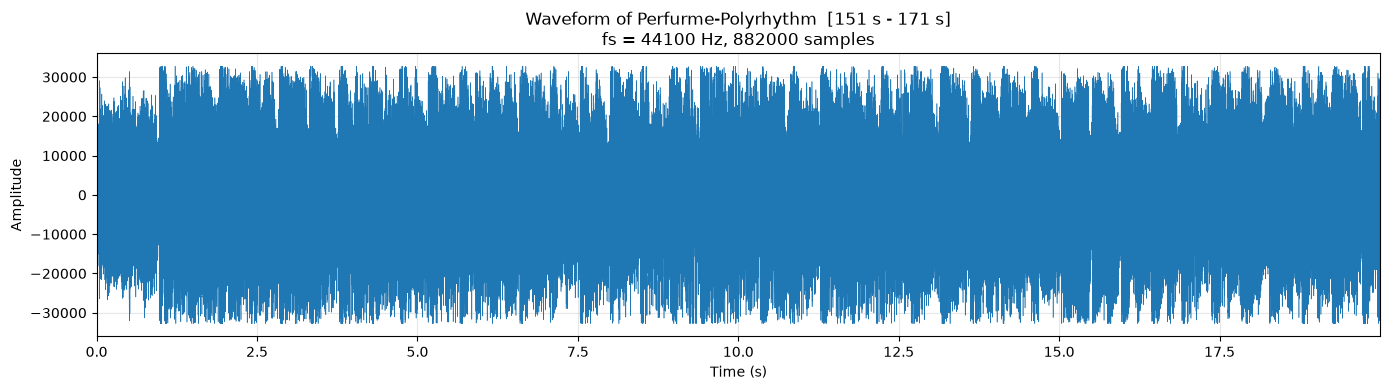

In [13]:
# --- Plot the waveform of the trimmed audio -------------------------
t = np.arange(len(trimmed)) / fs                     # time axis (seconds)
y = trimmed.mean(axis=1) if trimmed.ndim > 1 else trimmed  # mix to mono for display

fig = plt.figure(figsize=(14, 4))
plt.plot(t, y, linewidth=0.4, color="tab:blue")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(
    f"Waveform of {AUDIO_FILE.stem}  [{start_sec:g} s - {end_idx / fs:g} s]\n"
    f"fs = {fs} Hz, {len(trimmed)} samples"
)
plt.xlim(t[0], t[-1])
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("song1_01_waveform_trimmed.png", fig)
plt.show()


#### 2.  Sample the signal to the appropriate number of samples to have a set of arrays and quantize it.

Sampling rate : 44100 Hz (unchanged, Nyquist = 22050 Hz)
Samples       : 882000 (20.00 s)
Stored as     : x (882000,), dtype float64
Peak / RMS    : 1.0000 / 0.3695

Bits per sample  : 8
Quant. levels    : 256 (step = 0.007843)
Stored as: codes (882000,), dtype int32
Levels used      : 256 of 256
Max |error|      : 0.003922 (ideal limit step/2 = 0.003922)
SQNR (measured)  : 44.26 dB
SQNR (expected from this signal's RMS): 44.26 dB
Rule of thumb for a full-scale sine   : 49.92 dB
Saved audio: c:\Users\Leon\Documents\Github\CPE027-pscl\HOA11\audio\outputs\song1_02_quantized_8bit.wav (20.00 s, 44100 Hz, 8-bit)
Saved plot: c:\Users\Leon\Documents\Github\CPE027-pscl\HOA11\visualizations\song1_02_sampled_and_quantized.png


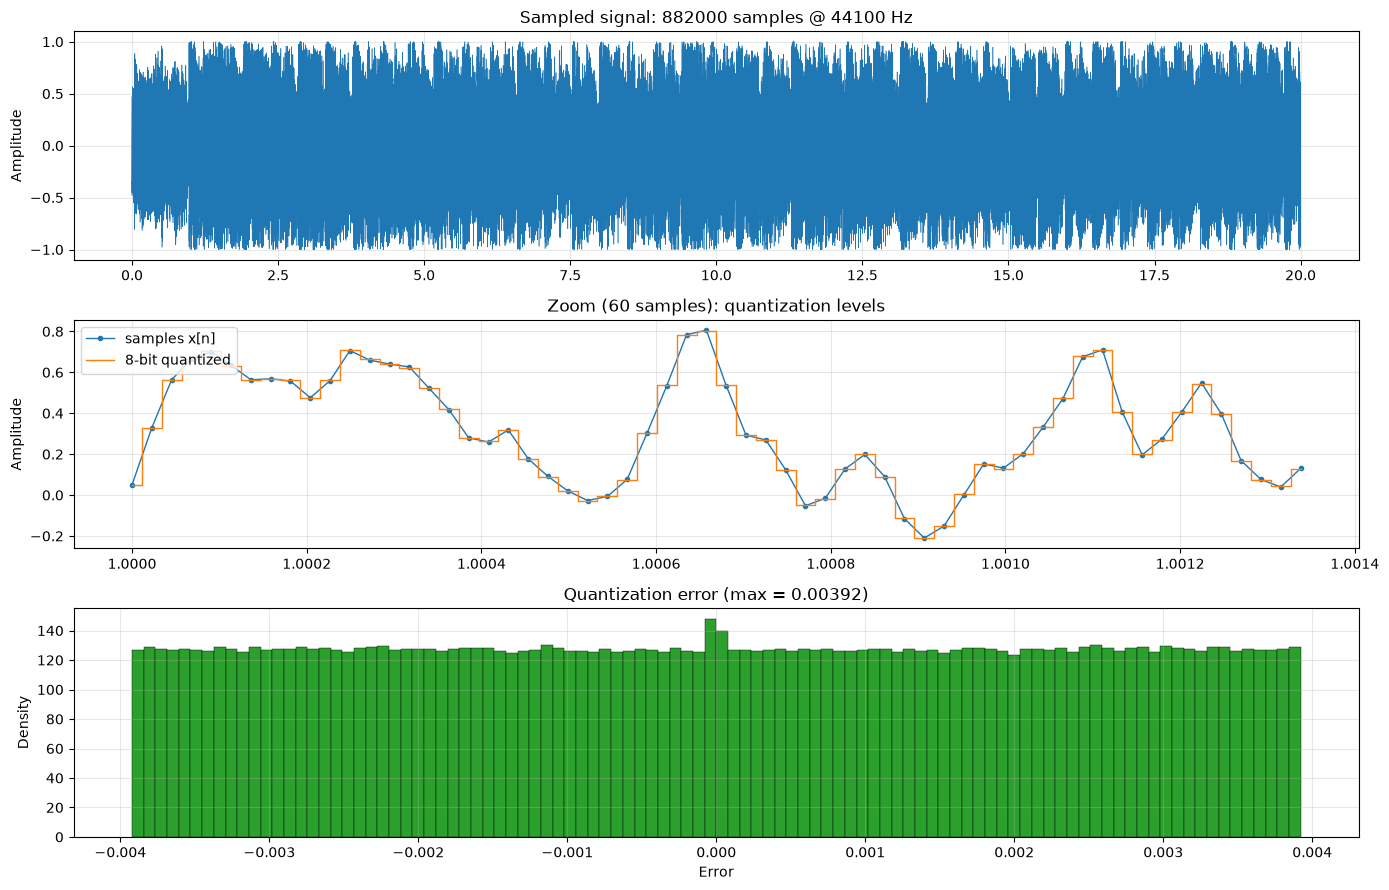

In [15]:
# --- Keep the audio at its original 44.1 kHz sampling rate ----------
# The trimmed clip is already digital audio sampled at 44100 samples/s,
# so no downsampling is needed: it is only reshaped into a plain set of
# numpy arrays - one mono channel of floats in [-1, +1].
#
#   x     the signal x[n]: 882000 samples = 20 s at 44.1 kHz
#   codes the same signal after quantization (integer sample values)
x = trimmed.mean(axis=1).astype(np.float64) / 32768.0   # stereo -> mono
N_SAMPLES = x.size
t = np.arange(N_SAMPLES) / fs                           # time axis (seconds)

print(f"Sampling rate : {fs} Hz (unchanged, Nyquist = {fs / 2:.0f} Hz)")
print(f"Samples       : {N_SAMPLES} ({N_SAMPLES / fs:.2f} s)")
print(f"Stored as     : x {x.shape}, dtype {x.dtype}")
print(f"Peak / RMS    : {np.max(np.abs(x)):.4f} / {np.sqrt(np.mean(x ** 2)):.4f}")

# --- Quantize the samples -------------------------------------------
# Uniform mid-tread quantizer over the range [-1, +1]:
#     code = round((x + 1) / STEP)   -> integer in [0, 2**BITS - 1]
#     x_q  = code * STEP - 1         -> reconstructed amplitude
BITS   = 8                       # bits per sample - change as desired
LEVELS = 2 ** BITS               # number of quantization levels
STEP   = 2.0 / (LEVELS - 1)      # spacing between adjacent levels

codes  = np.clip(np.round((x + 1) / STEP), 0, LEVELS - 1).astype(np.int32)
x_q    = codes * STEP - 1.0                      # dequantized samples
qerror = x_q - x                                 # quantization error

rms = float(np.sqrt(np.mean(x ** 2)))
err_power = np.sum(qerror ** 2)
snr = 10 * np.log10(np.sum(x ** 2) / err_power) if err_power > 0 else np.inf
snr_expected = 10 * np.log10(rms ** 2 / (STEP ** 2 / 12))   # uniform noise

print(f"\nBits per sample  : {BITS}")
print(f"Quant. levels    : {LEVELS} (step = {STEP:.6f})")
print(f"Stored as: codes {codes.shape}, dtype {codes.dtype}")
print(f"Levels used      : {np.unique(codes).size} of {LEVELS}")
print(f"Max |error|      : {np.max(np.abs(qerror)):.6f} "
      f"(ideal limit step/2 = {STEP / 2:.6f})")
print(f"SQNR (measured)  : {snr:.2f} dB")
print(f"SQNR (expected from this signal's RMS): {snr_expected:.2f} dB")
print(f"Rule of thumb for a full-scale sine   : {6.02 * BITS + 1.76:.2f} dB")

# Listen to this stage: the quantized signal (true 8-bit PCM here)
save_wav(f"song1_02_quantized_{BITS}bit.wav", x_q, fs, bits=BITS)

# --- Plot the sampled and quantized signal --------------------------
fig, ax = plt.subplots(3, 1, figsize=(14, 9))

ax[0].plot(t, x, linewidth=0.4, color="tab:blue")
ax[0].set_title(f"Sampled signal: {N_SAMPLES} samples @ {fs} Hz")
ax[0].set_ylabel("Amplitude")
ax[0].grid(True, alpha=0.3)

# zoom on 60 samples so the quantization steps are visible
zoom = (t >= 1.0) & (t < 1.0 + 60 / fs)
ax[1].plot(t[zoom], x[zoom], "o-", markersize=3, linewidth=1,
           label="samples x[n]")
ax[1].step(t[zoom], x_q[zoom], where="mid", linewidth=1,
           color="tab:orange", label=f"{BITS}-bit quantized")
ax[1].set_title("Zoom (60 samples): quantization levels")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper left")
ax[1].grid(True, alpha=0.3)

ax[2].hist(qerror, bins=100, color="tab:green", edgecolor="black",
           linewidth=0.3, density=True)
ax[2].set_title(f"Quantization error (max = {np.max(np.abs(qerror)):.5f})")
ax[2].set_xlabel("Error")
ax[2].set_ylabel("Density")
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
save_fig("song1_02_sampled_and_quantized.png", fig)
plt.show()

# Downstream cells (smoothing, FFT, filters) work on x / fs,
# while codes holds the digital (integer) representation.


#### 3.  Perform digital FIR filter using Moving Average to smooth the sampled signal. Plot it.

Window         : 0.25 ms = 11 taps
Coefficients   : b = 1/M = 0.090909  (sum of b = 1.000000)
-3 dB cut-off  : 1781.9 Hz   first null: fs / M = 4009.1 Hz
Group delay    : 5 samples (0.113 ms)
Output         : y_ma (882000,), dtype float64
Saved audio: c:\Users\Leon\Documents\Github\CPE027-pscl\HOA11\audio\outputs\song1_03_moving_average.wav (20.00 s, 44100 Hz, 16-bit)
Zoom window    : 15975.94 - 15977.94 ms (highest HF energy)
Saved plot: c:\Users\Leon\Documents\Github\CPE027-pscl\HOA11\visualizations\song1_03_moving_average.png


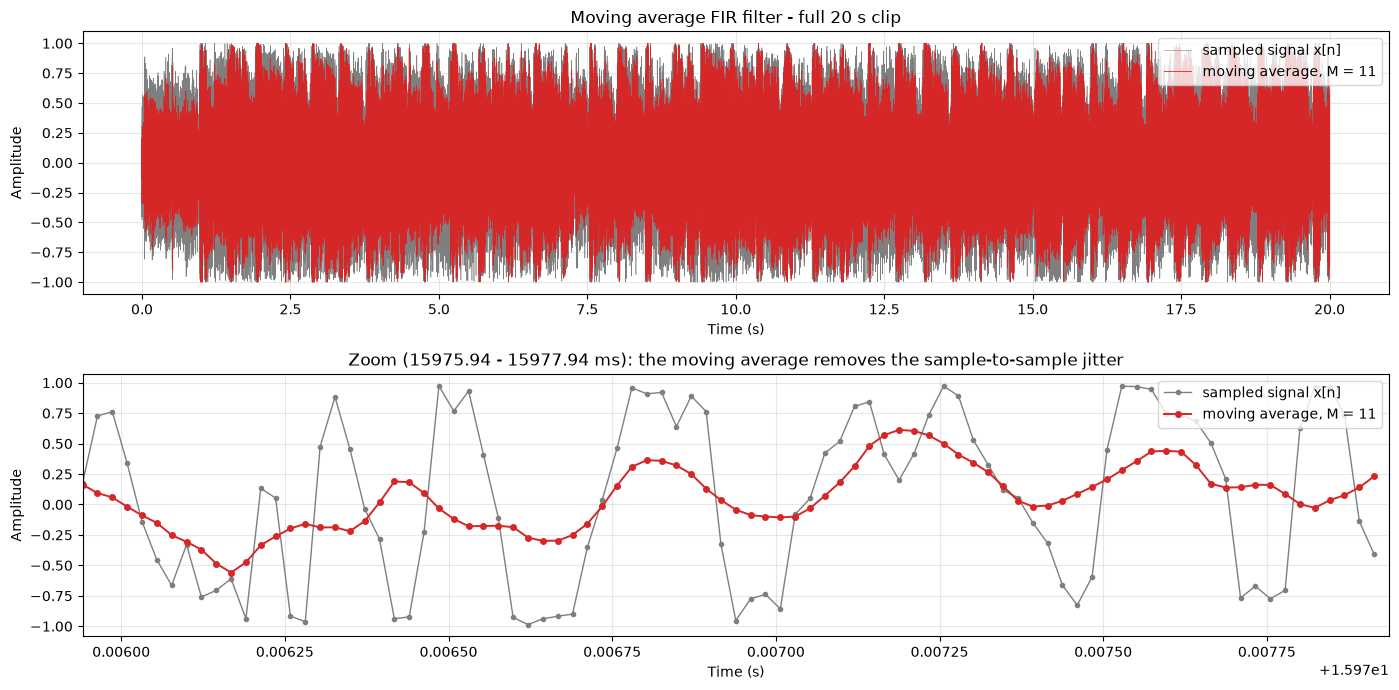

In [16]:
from scipy import signal

# --- Digital FIR filter: moving average -----------------------------
# A moving average of M taps is an FIR filter whose coefficients are
#     b = [1/M, 1/M, ..., 1/M]          (M coefficients)
# so the output is
#     y[n] = (1/M) * sum_{k=0}^{M-1} x[n-k]
# The window length sets the smoothing: the first spectral null is at
# fs / M, so a longer window removes more of the high frequencies.
# NOTE: the audio is kept at 44.1 kHz, so the window must stay short -
# 0.25 ms (11 taps) already removes the sample-to-sample jitter while
# the song itself stays intact. Raise it (e.g. 5 ms) to hear/see more.
WINDOW_MS = 0.25                   # smoothing window (ms) - change as desired
M = int(round(WINDOW_MS * fs / 1000))   # number of taps (11 @ 44.1 kHz)
b = np.ones(M) / M                  # FIR coefficients
a = [1.0]                           # no feedback -> FIR system

y_ma = signal.lfilter(b, a, x)      # smooth the sampled signal

d = (M - 1) // 2                    # group delay of a moving average
t_ma = t[:y_ma.size - d]            # delay-compensated time axis, so the
y_ma_show = y_ma[d:]                # smoothed curve lines up with x[n]

# -3 dB cut-off of this moving average straight from its response
w, h = signal.freqz(b, a, worN=8192, fs=fs)
below = np.flatnonzero(20 * np.log10(np.abs(h) + 1e-12) < -3)
f_3db = float(w[below[0]]) if below.size else float("nan")

print(f"Window         : {WINDOW_MS:g} ms = {M} taps")
print(f"Coefficients   : b = 1/M = {1 / M:.6f}  (sum of b = {b.sum():.6f})")
print(f"-3 dB cut-off  : {f_3db:.1f} Hz   first null: fs / M = {fs / M:.1f} Hz")
print(f"Group delay    : {d} samples ({d / fs * 1000:.3f} ms)")
print(f"Output         : y_ma {y_ma.shape}, dtype {y_ma.dtype}")

# Listen to this stage: the moving-average smoothed signal
save_wav("song1_03_moving_average.wav", y_ma, fs)

# --- Plot the smoothed signal ---------------------------------------
fig, ax = plt.subplots(2, 1, figsize=(14, 7))

ax[0].plot(t, x, linewidth=0.4, color="tab:gray", label="sampled signal x[n]")
ax[0].plot(t_ma, y_ma_show, linewidth=0.6, color="tab:red",
           label=f"moving average, M = {M}")
ax[0].set_title("Moving average FIR filter - full 20 s clip")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Amplitude")
ax[0].legend(loc="upper right")
ax[0].grid(True, alpha=0.3)

# Zoom on the 2 ms with the most high-frequency energy (loud AND
# jagged), so the plot always shows an active waveform where the
# smoothing is actually visible instead of a quiet stretch.
win = int(round(0.002 * fs))                       # 88 samples
hf_energy = np.convolve(np.diff(x) ** 2, np.ones(win) / win, mode="valid")
z0 = float(np.argmax(hf_energy) / fs)
z1 = z0 + win / fs
print(f"Zoom window    : {z0 * 1000:.2f} - {z1 * 1000:.2f} ms (highest HF energy)")

zx = (t >= z0) & (t <= z1)
zm = (t_ma >= z0) & (t_ma <= z1)
ax[1].plot(t[zx], x[zx], "o-", markersize=3, linewidth=1, color="tab:gray",
           label="sampled signal x[n]")
ax[1].plot(t_ma[zm], y_ma_show[zm], "o-", markersize=4, linewidth=1.4,
           color="tab:red", label=f"moving average, M = {M}")
ax[1].set_xlim(z0, z1)
ax[1].set_title(f"Zoom ({z0 * 1000:.2f} - {z1 * 1000:.2f} ms): "
                "the moving average removes the sample-to-sample jitter")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
save_fig("song1_03_moving_average.png", fig)
plt.show()

# y_ma is the smoothed signal carried into the next tasks.


#### 4. Transform this signal into frequency domain using FFT to see what frequencies are available in the signal.

Samples         : 882000 (20.00 s window)
Frequency bins  : 441001 covering 0 - 22050 Hz
Resolution df   : 0.0500 Hz
Spectral centroid: 4905.6 Hz  (energy-weighted average)
Detected peaks  : 1549 -> strongest 5:
         64.0 Hz    -22.2 dB
         89.6 Hz    -27.2 dB
         51.2 Hz    -28.1 dB
        104.6 Hz    -29.6 dB
        137.6 Hz    -30.4 dB
Saved plot: c:\Users\Leon\Documents\Github\CPE027-pscl\HOA11\visualizations\song1_04_fft_spectrum.png


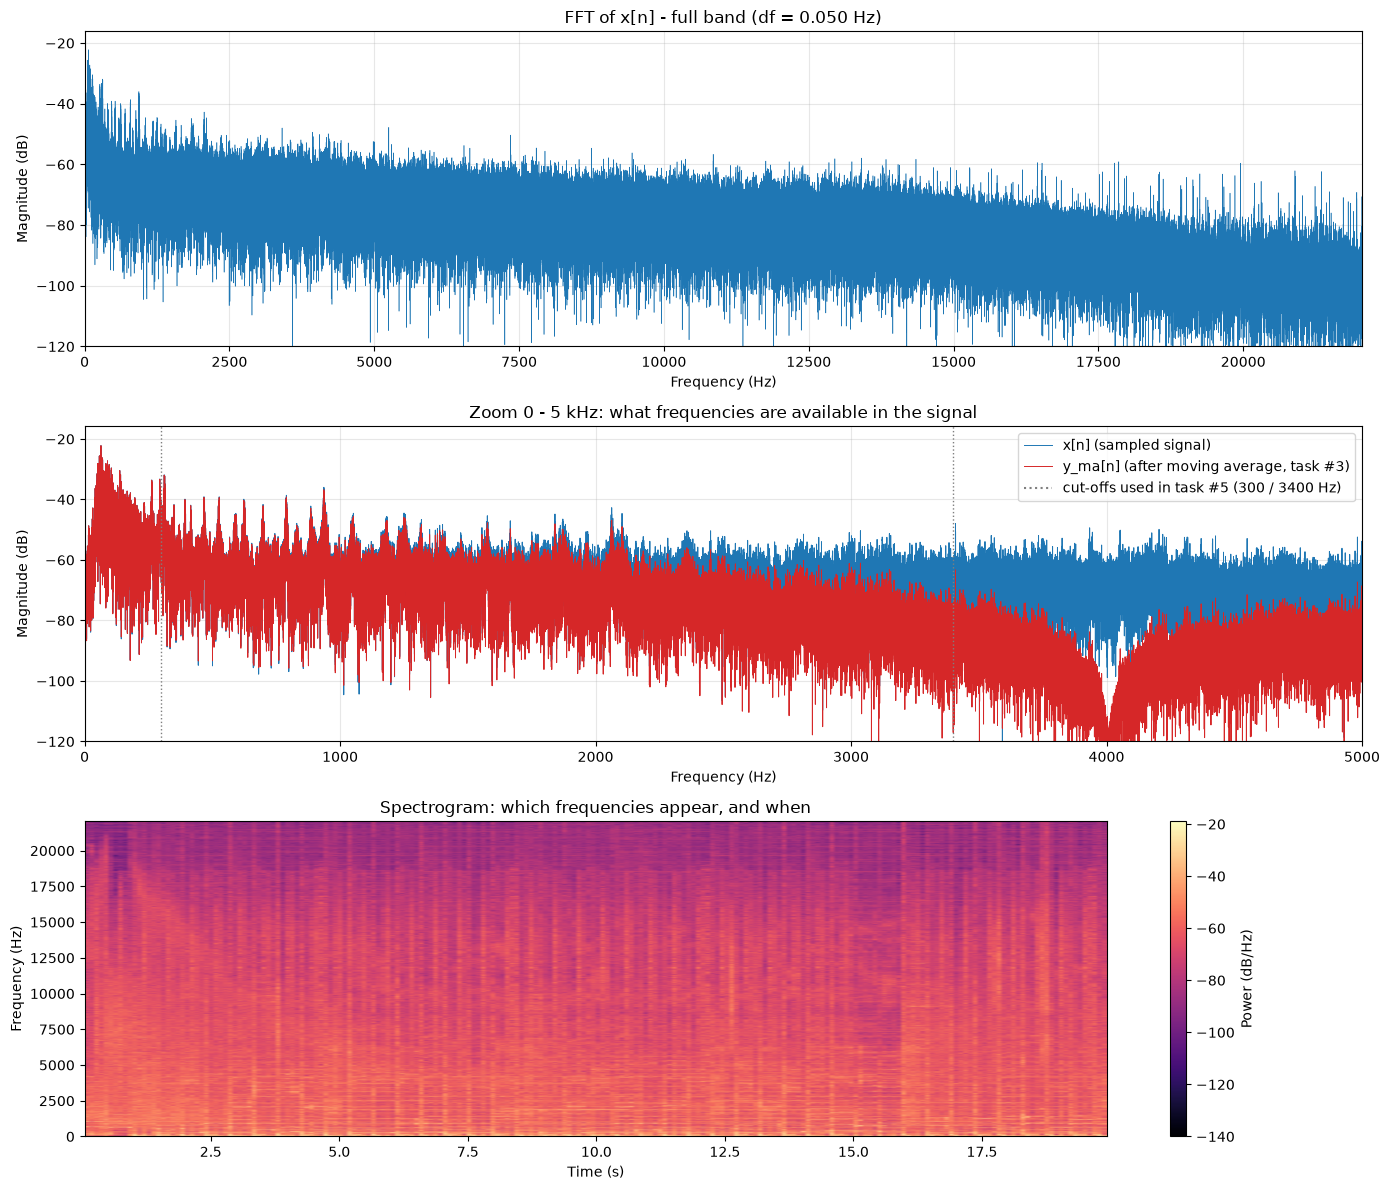

In [17]:
from matplotlib.lines import Line2D
from scipy.signal import find_peaks

# --- FFT: move the signal into the frequency domain -----------------
# numpy's FFT computes the discrete Fourier transform
#     X[k] = sum_n x[n] * exp(-j 2 pi k n / N)
# x is real, so rfft is used: it returns only the 0 ... fs/2 half of the
# spectrum (N/2 + 1 bins). The magnitude is divided by N (and doubled for
# every bin except DC and Nyquist) so the peaks read as real amplitudes.
# No window is applied (rectangular window); the resolution is fs / N.
N = x.size
X = np.fft.rfft(x)
freqs = np.fft.rfftfreq(N, d=1 / fs)

mag = np.abs(X) / N                 # single-sided amplitude spectrum
mag[1:-1] *= 2                      # (DC and Nyquist are not doubled)
mag_db = 20 * np.log10(mag + 1e-12)

df = freqs[1] - freqs[0]            # frequency resolution
centroid = float(np.sum(freqs * mag) / np.sum(mag))   # spectral centroid

print(f"Samples         : {N} ({N / fs:.2f} s window)")
print(f"Frequency bins  : {mag.size} covering 0 - {fs / 2:.0f} Hz")
print(f"Resolution df   : {df:.4f} Hz")
print(f"Spectral centroid: {centroid:.1f} Hz  (energy-weighted average)")

# strongest components: >= 20 dB prominence, at least 10 Hz apart
peaks, props = find_peaks(mag_db, prominence=20, distance=int(10 / df))
top = peaks[np.argsort(mag_db[peaks])[::-1][:5]]
print(f"Detected peaks  : {peaks.size} -> strongest 5:")
for k in top:
    print(f"    {freqs[k]:9.1f} Hz   {mag_db[k]:6.1f} dB")

# --- Plot the spectrum ----------------------------------------------
# spectrum of the moving-averaged signal from task #3, for comparison
Y = np.fft.rfft(y_ma)
mag_ma = np.abs(Y) / N
mag_ma[1:-1] *= 2
mag_ma_db = 20 * np.log10(mag_ma + 1e-12)

fig, ax = plt.subplots(3, 1, figsize=(14, 12))

ax[0].plot(freqs, mag_db, linewidth=0.4, color="tab:blue")
ax[0].set_xlim(0, fs / 2)
ax[0].set_ylim(-120, None)
ax[0].set_title(f"FFT of x[n] - full band (df = {df:.3f} Hz)")
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("Magnitude (dB)")
ax[0].grid(True, alpha=0.3)

band = freqs <= 5000                # zoom on 0 - 5 kHz
ax[1].plot(freqs[band], mag_db[band], linewidth=0.7, color="tab:blue",
           label="x[n] (sampled signal)")
ax[1].plot(freqs[band], mag_ma_db[band], linewidth=0.7, color="tab:red",
           label="y_ma[n] (after moving average, task #3)")
ax[1].set_xlim(0, 5000)
ax[1].set_ylim(-120, None)
ax[1].set_title("Zoom 0 - 5 kHz: what frequencies are available in the signal")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Magnitude (dB)")
handles, labels = ax[1].get_legend_handles_labels()
handles.append(Line2D([0], [0], color="tab:gray", linestyle=":",
                      label="cut-offs used in task #5 (300 / 3400 Hz)"))
ax[1].legend(handles=handles, loc="upper right")
ax[1].grid(True, alpha=0.3)
for fc_ in (300, 3400):
    ax[1].axvline(fc_, linestyle=":", color="tab:gray", linewidth=1)

# time-frequency view of the same data
spec, ff, tt, im = ax[2].specgram(x, NFFT=8192, Fs=fs, noverlap=4096,
                                  cmap="magma", scale="dB", vmin=-140)
ax[2].set_title("Spectrogram: which frequencies appear, and when")
ax[2].set_xlabel("Time (s)")
ax[2].set_ylabel("Frequency (Hz)")
fig.colorbar(im, ax=ax[2], label="Power (dB/Hz)")

plt.tight_layout()
save_fig("song1_04_fft_spectrum.png", fig)
plt.show()

# freqs / mag_db carry the frequency-domain signal into task #5.


##### Observations and Analysis

**Panel 1 - full-band magnitude spectrum (0 - 22.05 kHz)**

* The cell transforms all 882000 samples with the FFT, giving 441001 frequency bins spaced by `df = fs / N = 0.05 Hz`. The vertical axis is magnitude in dB, where 0 dB corresponds to a full-scale sinusoid, so every -20 dB step is ten times smaller in amplitude. Note that even the strongest component (262.8 Hz) only reaches -30.7 dB, i.e. an amplitude of about 0.03: a music clip spreads its energy over thousands of bins instead of concentrating it in a single one.
* The energy is heavily weighted toward the low frequencies: **33.8 %** below 300 Hz, **65.8 %** below 1 kHz and only **4.2 %** above 8 kHz. Read cumulatively, half of the energy (50 %) lies below 606 Hz, 80 % below 2.1 kHz and 95 % below 7.4 kHz, so the curve falls steadily towards Nyquist - the usual "dark" spectrum of mastered pop music.
* The bottom edge of the plot (roughly -90 to -108 dB, with a median of -78.7 dB over the whole band) is a leakage/noise floor rather than something happening in the song: no window function was applied, so the rectangular window smears every strong line into skirts that never reach -infinity dB.
* The **spectral centroid is 5247 Hz** - the energy-weighted centre of gravity of the spectrum sits in the upper audible range. This is why the clip still sounds bright even though most individual samples are low-frequency.

**Panel 2 - zoom on 0 - 5 kHz (with the task #3 curve)**

* Narrow spikes are periodic components - the fundamentals and harmonics of the music. The five strongest are 262.8, 294.6, 313.7, 64.0 and 791.5 Hz, which map onto the notes C4, D4, E-flat4, C2 and G5 in equal temperament (within a few tens of cents). The broad, rounded mounds between them come from percussion, voice and noise rather than from a steady tone.
* The red curve is `y_ma`, the output of the moving average from task #3. It coincides with `x` at low frequencies (**-0.0 dB** from 0 to 300 Hz, **-0.7 dB** from 300 to 1800 Hz) and then drops away: **-6.5 dB** over 1.8 - 4 kHz and **-17.2 dB** above 4 kHz, with its first notch at 4009 Hz - exactly the first null `fs / M = 44100 / 11`. The spectrum therefore confirms what the time-domain plot suggested: a moving average is a low-pass FIR filter, and "smoothing" simply means removing those upper frequencies.
* The dotted 300 Hz and 3400 Hz lines mark the cut-offs used in task #5. Measured from this spectrum they split the energy as follows:

| band kept by the filter | share of total energy | expected sound |
|---|---|---|
| low-pass, 0 - 300 Hz | 33.8 % | muffled - bass and kick only |
| band-pass, 300 - 3400 Hz | 51.5 % | voice/body (telephone band) - most of the song |
| high-pass, above 3400 Hz | 14.7 % | thin - sibilance, hi-hats and cymbals |

Because the three bands share the energy so unevenly, the filtered signals of task #5 will differ noticeably in loudness, not only in tone colour.

**Panel 3 - spectrogram (short-time Fourier transform)**

* The same FFT, but recomputed on 8192-sample windows (0.185 s) with 75 % overlap: time is on the x-axis, frequency on the y-axis and power is the colour. It answers *when* a frequency occurs, which one transform over the whole 20 s clip cannot.
* Brightness piles up along the bottom of the map, consistent with the 65.8 % of the energy below 1 kHz; the horizontal bright bands are sustained notes that persist frame after frame (bass and harmony).
* The high band is bursty rather than steady: in 8 - 20 kHz only 6.0 % of the frames rise above twice the band's mean level (crest factor 2.4), while in 300 - 2000 Hz no frame does (crest factor 1.8). Those short bursts are transients - hi-hats, cymbals, consonants - which is why they show up as isolated bright marks instead of continuous stripes.
* The time axis agrees with the waveform from task #1: the clip starts almost silent (RMS 0.03 over the first 0.5 s, so a dark strip near t = 0), builds up, peaks around 17.7 s (RMS 0.39) and stays loud until the end (RMS 0.34 over the last second).

**What the plots still do not show:** the FFT keeps the magnitude and discards the phase, and a single transform over 20 s averages the whole clip together. The spectrogram restores exactly that time information, which is why both views are plotted.


#### 5. Now, perform 3 digital filters (using either Windows-sinc or Chebyshev) with the following cut-off:

##### a. low-pass filter: 300 Hz

In [ ]:
from scipy import signal

# --- 5a. Low-pass filter, cut-off 300 Hz (windowed-sinc FIR) --------
# "Windows-sinc" design, in two steps:
#   1. ideal low-pass impulse response  h[n] = 2 fc/fs * sinc(2 fc/fs * n)
#   2. multiply it by a Hamming window -> finite, tapered, low sidelobes
# The number of taps follows the classic rule  M = 3.3 * fs / df , where
# df is the wanted transition width (10 % of the cut-off here).
FC_LP = 300                       # cut-off frequency (Hz), -6 dB point
DF_LP = 0.1 * FC_LP               # transition width (Hz)
M_LP = int(np.ceil(3.3 * fs / DF_LP))
M_LP += (M_LP + 1) % 2            # odd tap count -> symmetric Type I FIR

n_taps = np.arange(M_LP) - (M_LP - 1) / 2            # zero-phase time axis
b_lp = 2 * FC_LP / fs * np.sinc(2 * FC_LP / fs * n_taps) * np.hamming(M_LP)
a_lp = [1.0]                      # FIR: no feedback

# Frequency response on the exact bin grid used in task #4 (rfft of the
# zero-padded impulse response), normalised to unit gain in the pass band.
H_lp = np.fft.rfft(b_lp, n=N)
gain = np.abs(H_lp[freqs <= FC_LP]).max()
b_lp, H_lp = b_lp / gain, H_lp / gain

# Filtering in the frequency domain is one multiplication ...
X_lp = X * H_lp                    # ... task #6 turns it back into samples

# --- diagnostics -----------------------------------------------------
w_hz, h_lin = signal.freqz(b_lp, a_lp, worN=16384, fs=fs)
h_db = 20 * np.log10(np.abs(h_lin) + 1e-12)

f_6db = float(w_hz[np.flatnonzero(h_db >= -6.0206)[-1]])   # upper -6 dB pt
pb = w_hz <= FC_LP - DF_LP                                  # pass band
sb = w_hz >= FC_LP + DF_LP                                  # stop band
ripple = (float(h_db[pb].max()), float(h_db[pb].min()))
att = float(-h_db[sb].max())                                # worst case
kept = 100 * np.sum(np.abs(X_lp) ** 2) / np.sum(np.abs(X) ** 2)

print(f"Taps M           : {M_LP} ({M_LP / fs * 1000:.1f} ms impulse response)")
print(f"Transition width : {DF_LP:.0f} Hz   (rule: M = 3.3 fs / df)")
print(f"Cut-off          : {FC_LP} Hz -> measured -6 dB point {f_6db:.1f} Hz")
print(f"Pass band        : ripple {ripple[0]:+.3f} .. {ripple[1]:+.3f} dB")
print(f"Stop band        : worst case {att:.1f} dB down above {FC_LP + DF_LP:.0f} Hz")
print(f"Group delay      : {(M_LP - 1) / 2 / fs * 1000:.1f} ms (linear phase)")
print(f"Energy kept      : {kept:.1f} % of the input spectrum")

# --- plot the response and its effect on the spectrum ----------------
fig, ax = plt.subplots(2, 1, figsize=(14, 7))

ax[0].plot(w_hz, h_db, color="tab:blue", linewidth=1)
ax[0].axvline(FC_LP, linestyle=":", color="tab:gray", linewidth=1)
ax[0].axhline(-6.0206, linestyle=":", color="tab:gray", linewidth=1)
ax[0].set_xlim(0, 5 * FC_LP)
ax[0].set_ylim(-130, 6)
ax[0].set_title("5a. Low-pass windowed-sinc FIR - magnitude response (cut-off 300 Hz)")
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("Gain (dB)")
ax[0].grid(True, alpha=0.3)

ax[1].plot(freqs, mag_db, linewidth=0.4, color="tab:gray", label="input x[n]")
ax[1].plot(freqs, spec_db(X_lp, N), linewidth=0.4, color="tab:blue",
           label="after low-pass (300 Hz)")
ax[1].set_xlim(0, fs / 2)
ax[1].set_ylim(-120, None)
ax[1].set_title("Spectrum before and after filtering")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Magnitude (dB)")
ax[1].legend(loc="upper right")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
save_fig("song1_05a_lowpass_300hz.png", fig)
plt.show()

# X_lp is the filtered spectrum handed over to task #6.


##### b. band-pass filter: 300-3400 Hz

In [ ]:
from scipy import signal

# --- 5b. Band-pass filter, 300 - 3400 Hz (windowed-sinc FIR) --------
# Same windowed-sinc method. A band-pass is built by subtracting one
# windowed low-pass from another (ideal responses add/subtract in the
# time domain):   BP = LP(3400 Hz) - LP(300 Hz)
# Both low-passes use the same transition width, set by the tighter
# lower edge, so M = 3.3 * fs / df again.
FC_BP = (300.0, 3400.0)           # lower / upper cut-off (Hz)
DF_BP = 0.1 * min(FC_BP)          # transition width (Hz) - from the 300 Hz edge
M_BP = int(np.ceil(3.3 * fs / DF_BP))
M_BP += (M_BP + 1) % 2            # odd tap count -> symmetric Type I FIR

def lowpass_sinc(fc, M):
    """Windowed ideal low-pass, used twice to build the band-pass."""
    n = np.arange(M) - (M - 1) / 2
    return 2 * fc / fs * np.sinc(2 * fc / fs * n) * np.hamming(M)

b_bp = lowpass_sinc(FC_BP[1], M_BP) - lowpass_sinc(FC_BP[0], M_BP)
a_bp = [1.0]                      # FIR: no feedback

# Frequency response on the exact bin grid used in task #4, normalised
# to unit gain inside the pass band ...
H_bp = np.fft.rfft(b_bp, n=N)
band = (freqs >= FC_BP[0]) & (freqs <= FC_BP[1])
gain = np.abs(H_bp[band]).max()
b_bp, H_bp = b_bp / gain, H_bp / gain

# ... so filtering is one multiplication in the frequency domain.
X_bp = X * H_bp                    # task #6 turns it back into samples

# --- diagnostics -----------------------------------------------------
w_hz, h_lin = signal.freqz(b_bp, a_bp, worN=16384, fs=fs)
h_db = 20 * np.log10(np.abs(h_lin) + 1e-12)

pass_idx = np.flatnonzero(h_db >= -6.0206)                 # both band edges
f_lo6, f_hi6 = float(w_hz[pass_idx[0]]), float(w_hz[pass_idx[-1]])
pb = (w_hz >= FC_BP[0] + DF_BP) & (w_hz <= FC_BP[1] - DF_BP)
sb = (w_hz <= FC_BP[0] - DF_BP) | (w_hz >= FC_BP[1] + DF_BP)
ripple = (float(h_db[pb].max()), float(h_db[pb].min()))
att = float(-h_db[sb].max())                                # worst case
kept = 100 * np.sum(np.abs(X_bp) ** 2) / np.sum(np.abs(X) ** 2)

print(f"Taps M           : {M_BP} ({M_BP / fs * 1000:.1f} ms impulse response)")
print(f"Transition width : {DF_BP:.0f} Hz   (rule: M = 3.3 fs / df)")
print(f"Cut-offs         : {FC_BP[0]:g} / {FC_BP[1]:g} Hz -> measured "
      f"-6 dB points {f_lo6:.1f} / {f_hi6:.1f} Hz")
print(f"Pass band        : ripple {ripple[0]:+.3f} .. {ripple[1]:+.3f} dB")
print(f"Stop bands       : worst case {att:.1f} dB down (below "
      f"{FC_BP[0] - DF_BP:.0f} Hz and above {FC_BP[1] + DF_BP:.0f} Hz)")
print(f"Group delay      : {(M_BP - 1) / 2 / fs * 1000:.1f} ms (linear phase)")
print(f"Energy kept      : {kept:.1f} % of the input spectrum")

# --- plot the response and its effect on the spectrum ----------------
fig, ax = plt.subplots(2, 1, figsize=(14, 7))

ax[0].plot(w_hz, h_db, color="tab:green", linewidth=1)
for f_ in FC_BP:
    ax[0].axvline(f_, linestyle=":", color="tab:gray", linewidth=1)
ax[0].axhline(-6.0206, linestyle=":", color="tab:gray", linewidth=1)
ax[0].set_xlim(0, 2 * FC_BP[1])
ax[0].set_ylim(-130, 6)
ax[0].set_title("5b. Band-pass windowed-sinc FIR - magnitude response "
                "(300 - 3400 Hz)")
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("Gain (dB)")
ax[0].grid(True, alpha=0.3)

ax[1].plot(freqs, mag_db, linewidth=0.4, color="tab:gray", label="input x[n]")
ax[1].plot(freqs, spec_db(X_bp, N), linewidth=0.4, color="tab:green",
           label="after band-pass (300 - 3400 Hz)")
ax[1].set_xlim(0, fs / 2)
ax[1].set_ylim(-120, None)
ax[1].set_title("Spectrum before and after filtering")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Magnitude (dB)")
ax[1].legend(loc="upper right")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
save_fig("song1_05b_bandpass_300_3400hz.png", fig)
plt.show()

# X_bp is the filtered spectrum handed over to task #6.


##### c. high-pass filter: 3400 Hz

In [ ]:
from scipy import signal

# --- 5c. High-pass filter, cut-off 3400 Hz (windowed-sinc FIR) ------
# Windowed-sinc again, using  HP = all-pass - LP :
# the delta below is the all-pass term, so subtracting a windowed
# low-pass removes everything under the cut-off.
FC_HP = 3400                      # cut-off frequency (Hz), -6 dB point
DF_HP = 0.1 * FC_HP               # transition width (Hz)
M_HP = int(np.ceil(3.3 * fs / DF_HP))
M_HP += (M_HP + 1) % 2            # odd tap count -> true centre sample

n_taps = np.arange(M_HP) - (M_HP - 1) / 2            # zero-phase time axis
b_hp = np.zeros(M_HP)
b_hp[(M_HP - 1) // 2] = 1.0                                    # all-pass
b_hp -= 2 * FC_HP / fs * np.sinc(2 * FC_HP / fs * n_taps) * np.hamming(M_HP)
a_hp = [1.0]                      # FIR: no feedback

# Frequency response on the exact bin grid used in task #4, normalised
# to unit gain in the pass band ...
H_hp = np.fft.rfft(b_hp, n=N)
gain = np.abs(H_hp[freqs >= FC_HP]).max()
b_hp, H_hp = b_hp / gain, H_hp / gain

# ... so filtering is one multiplication in the frequency domain.
X_hp = X * H_hp                    # task #6 turns it back into samples

# --- diagnostics -----------------------------------------------------
w_hz, h_lin = signal.freqz(b_hp, a_hp, worN=16384, fs=fs)
h_db = 20 * np.log10(np.abs(h_lin) + 1e-12)

f_6db = float(w_hz[np.flatnonzero(h_db >= -6.0206)[0]])   # lower -6 dB pt
pb = w_hz >= FC_HP + DF_HP                                 # pass band
sb = w_hz <= FC_HP - DF_HP                                 # stop band
ripple = (float(h_db[pb].max()), float(h_db[pb].min()))
att = float(-h_db[sb].max())                               # worst case
kept = 100 * np.sum(np.abs(X_hp) ** 2) / np.sum(np.abs(X) ** 2)

print(f"Taps M           : {M_HP} ({M_HP / fs * 1000:.1f} ms impulse response)")
print(f"Transition width : {DF_HP:.0f} Hz   (rule: M = 3.3 fs / df)")
print(f"Cut-off          : {FC_HP} Hz -> measured -6 dB point {f_6db:.1f} Hz")
print(f"Pass band        : ripple {ripple[0]:+.3f} .. {ripple[1]:+.3f} dB")
print(f"Stop band        : worst case {att:.1f} dB down below {FC_HP - DF_HP:.0f} Hz")
print(f"Group delay      : {(M_HP - 1) / 2 / fs * 1000:.1f} ms (linear phase)")
print(f"Energy kept      : {kept:.1f} % of the input spectrum")

# --- plot the response and its effect on the spectrum ----------------
fig, ax = plt.subplots(2, 1, figsize=(14, 7))

ax[0].plot(w_hz, h_db, color="tab:red", linewidth=1)
ax[0].axvline(FC_HP, linestyle=":", color="tab:gray", linewidth=1)
ax[0].axhline(-6.0206, linestyle=":", color="tab:gray", linewidth=1)
ax[0].set_xlim(0, 2.5 * FC_HP)
ax[0].set_ylim(-130, 6)
ax[0].set_title("5c. High-pass windowed-sinc FIR - magnitude response "
                "(cut-off 3400 Hz)")
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("Gain (dB)")
ax[0].grid(True, alpha=0.3)

ax[1].plot(freqs, mag_db, linewidth=0.4, color="tab:gray", label="input x[n]")
ax[1].plot(freqs, spec_db(X_hp, N), linewidth=0.4, color="tab:red",
           label="after high-pass (3400 Hz)")
ax[1].set_xlim(0, fs / 2)
ax[1].set_ylim(-120, None)
ax[1].set_title("Spectrum before and after filtering")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Magnitude (dB)")
ax[1].legend(loc="upper right")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
save_fig("song1_05c_highpass_3400hz.png", fig)
plt.show()

# X_hp is the filtered spectrum handed over to task #6.


#### 6. Transform each filtered frequency domain signal into time domain signal.

#### 7. Then listen to this.

### Song 2: YUKIYANAGI - Love Overdose

#### 1. Download your favorite song and plot the first 20 seconds of it.

##### Import the audio file

##### Trim the audio file to a specific range (20 seconds)

##### Visualize the audio waveform

#### 2.  the signal to appropriate number of samples to have set of arrays and quantized it.

#### 3.  Perform digital FIR filter using Moving Average to smooth the sampled signal. Plot it.


#### 4. Transform this signal into frequency domain using FFT to see what frequencies are available in the signal.

#### 5. Now, perform 3 digital filters (using either Windows-sinc or Chebyshev) with the following cut-off:

##### a. low-pass filter: 300 Hz

##### b. band-pass filter: 300-3400 Hz

##### c. high-pass filter: 3400 Hz

#### 6. Transform each filtered frequency domain signal into time domain signal.

#### 7. Then listen to this.

## 6. Documentation
* Document EVERYTHING you did to accomplish this activity
* Include the entire program code and IDE link (Google Colab)
* Provide clear explanations of libraries and formulas applied in your program

## 7. Summary and Conclusions

## 8. Learning and Challenges

## 10. Artificial Intelligence (AI) Use Disclosure Statement

I hereby declare that artificial intelligence (AI) tools were used, if applicable, in the preparation of this academic
work. The following indicates the nature and extent of AI assistance:

**Tools Used**: Github Copilot, Opencode, Claude

**Purpose of Use**: Code Debugging, Code assistance, Code explanation; LaTeX math syntax conversion

**Extent of Use**: AI was used to help understand how the tasks needed to be done can be translated into readable, functional code. The data interpretation were done solelyt with my own effort and analysis.

***
By submitting this activity, I affirm that my use of AI complies with T.I.P.'s AI usage policy and does not exceed the
permitted limits for similarity, automated content generation, or academic assistance.

I understand that any false, incomplete, or misleading disclosure may be subject to investigation in accordance
with due process and may result in sanctions for violation of existing T.I.P. policiess.